## 1. Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
load_dotenv()

from src.models_llm import (
    get_groq_client, get_mistral_client,
    ask_groq, ask_mistral,
    build_zero_shot_prompt, build_few_shot_prompt,
    normalize_prediction,
    build_support_set, run_experiment,
    evaluate, compare_experiments, confusion_df,
)

## 2. Carregar dados

In [2]:
df_train = pd.read_csv("../data/processed/dataset_combined.csv", sep=";")
df_test  = pd.read_csv("../data/raw/dataset-exemplos.csv", sep=";")

print("Treino:")
print(df_train['Label'].value_counts())
print("\nTeste:")
print(df_test['Label'].value_counts())

Treino:
Label
Google       500
Human        500
Meta         500
OpenAI       500
Anthropic    330
Name: count, dtype: int64

Teste:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64


## 3. Clientes

In [3]:
from dotenv import load_dotenv

load_dotenv(dotenv_path="../src/.env")

print("GROQ:", bool(os.getenv("GROQ_API_KEY")))
print("MISTRAL:", bool(os.getenv("MISTRAL_API_KEY")))

groq_client    = get_groq_client()
mistral_client = get_mistral_client()

ask_groq_fn    = lambda prompt: ask_groq(prompt, client=groq_client)
ask_mistral_fn = lambda prompt: ask_mistral(prompt, client=mistral_client)

GROQ: True
MISTRAL: True


## 4. Support set (para few-shot)

In [4]:
support_1 = build_support_set(df_train, n_per_class=1)
support_2 = build_support_set(df_train, n_per_class=2)

pd.DataFrame(support_2)['Label'].value_counts()

Label
Meta         2
Google       2
OpenAI       2
Human        2
Anthropic    2
Name: count, dtype: int64

## 5. Zero-shot — Groq

In [6]:
zs_groq_preds, zs_groq_raw = run_experiment(
    df_test, ask_groq_fn,
    build_zero_shot_prompt, normalize_prediction,
    sleep_seconds=0.5,
)
print(zs_groq_raw[:5])
df_zs_groq = evaluate(zs_groq_preds, df_test, experiment_name="Groq zero-shot")

  [10/125] done
  [20/125] done
  [!] Error on row 27: Error code: 413 - {'error': {'message': 'Request Entity Too Large', 'type': 'invalid_request_error', 'code': 'request_too_large'}}
  [30/125] done
  [!] Error on row 31: Error code: 413 - {'error': {'message': 'Request Entity Too Large', 'type': 'invalid_request_error', 'code': 'request_too_large'}}


KeyboardInterrupt: 

## 6. Few-shot — Groq (1 exemplo por classe)

In [ ]:
fs_groq_preds, fs_groq_raw = run_experiment(
    df_test, ask_groq_fn,
    build_few_shot_prompt, normalize_prediction,
    support_examples=support_1,
    sleep_seconds=2,
)
df_fs_groq = evaluate(fs_groq_preds, df_test, experiment_name="Groq few-shot 1x")

## 7. Few-shot — Groq (2 exemplos por classe)

In [ ]:
# fs2_groq_preds, _ = run_experiment(
#     df_test, ask_groq_fn,
#     build_few_shot_prompt, normalize_prediction,
#     support_examples=support_2,
#     sleep_seconds=0.3,
# )
# df_fs2_groq = evaluate(fs2_groq_preds, df_test, experiment_name="Groq few-shot 2x")

## 8. Mistral Experiments

### 8.1 Zero-shot — Mistral

In [8]:
zs_mistral_preds, zs_mistral_raw = run_experiment(
    df_test, ask_mistral_fn,
    build_zero_shot_prompt, normalize_prediction,
    sleep_seconds=5,
)
df_zs_mistral = evaluate(zs_mistral_preds, df_test, experiment_name="Mistral zero-shot")

  [10/125] done
  [20/125] done
  [30/125] done
  [40/125] done
  [50/125] done
  [60/125] done
  [70/125] done
  [80/125] done
  [90/125] done
  [100/125] done
  [110/125] done
  [120/125] done

  Mistral zero-shot
  Accuracy : 0.4160  (125/125 parseable)
  Null rate: 0.00%
              precision    recall  f1-score   support

   Anthropic       0.00      0.00      0.00        23
      Google       0.00      0.00      0.00        16
       Human       0.42      1.00      0.59        52
        Meta       0.00      0.00      0.00        17
      OpenAI       0.00      0.00      0.00        17

    accuracy                           0.42       125
   macro avg       0.08      0.20      0.12       125
weighted avg       0.17      0.42      0.24       125



### 8.2 Few-shot — Mistral (1 exemplo por classe)

In [ ]:
time.sleep(10)
fs_mistral_preds, fs_mistral_raw = run_experiment(
    df_test, ask_mistral_fn,
    build_few_shot_prompt, normalize_prediction,
    support_examples=support_1,
    sleep_seconds=2,
)
df_fs_mistral = evaluate(fs_mistral_preds, df_test, experiment_name="Mistral few-shot 1x")

### 8.3 Few-shot — Mistral (2 exemplos por classe)

In [ ]:
# time.sleep(10)
# fs2_mistral_preds, _ = run_experiment(
#     df_test, ask_mistral_fn,
#     build_few_shot_prompt, normalize_prediction,
#     support_examples=support_2,
#     sleep_seconds=0.1,
# )
# df_fs2_mistral = evaluate(fs2_mistral_preds, df_test, experiment_name="Mistral few-shot 2x")

## 9. Comparação final

,experiment,accuracy,n_valid
1,Mistral zero-shot,0.416,125
0,Groq zero-shot,0.000,0


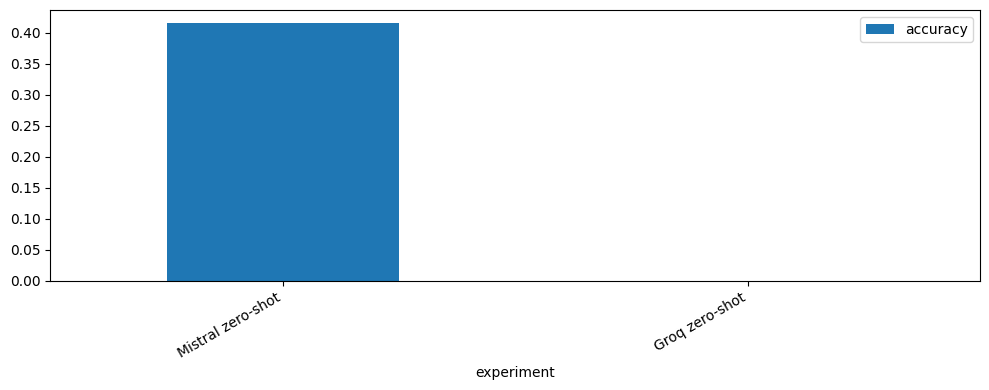

In [9]:
summary = compare_experiments({
    "Groq zero-shot":    zs_groq_preds,
    # "Groq few-shot 1x":  fs_groq_preds,
    # "Groq few-shot 2x":  fs2_groq_preds,
    "Mistral zero-shot": zs_mistral_preds,
    # "Mistral few-shot 1x":  fs_mistral_preds,
    # "Mistral few-shot 2x":  fs2_mistral_preds,
}, df_test)

display(summary)
summary.plot(x="experiment", y="accuracy", kind="bar", figsize=(10,4))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 10. Matriz de confusão do melhor modelo

In [ ]:
cm = confusion_df(fs2_groq_preds, df_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix — Groq few-shot 2x')
plt.show()

## 11. Guardar previsões

In [ ]:
df_test['predicted_label'] = fs2_groq_preds  # melhor modelo
os.makedirs("../data/predictions", exist_ok=True)
df_test.to_csv("../data/predictions/llm_groq_fewshot.csv", sep=";", index=False)